In [1]:
%%capture
!pip install -U langchain-community pymupdf

In [2]:
import os
import tiktoken
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn, torch
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from transformers import get_cosine_schedule_with_warmup
from langchain_community.document_loaders import PyMuPDFLoader

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")

In [3]:
@dataclass 
class config:
    d_model = 512
    stride = 1024
    seq_len = 1024
    batch_size = 1
    num_head = 16
    n_vocabs = 66869
    lr = 1e-4
    n_epochs = 50

    device_0 = "cuda:0"
    device_1 = "cuda:1"

    tokenizer = tiktoken.get_encoding("gpt2")
    pdf_pth = "/kaggle/input/datasets/edifonjimmy/diabetes-guideline/Guideline-For-Diabetes-Management-In-Nigeria-2nd-Edition.pdf"

In [4]:
loader = PyMuPDFLoader(file_path=config.pdf_pth)

doc = loader.load()

In [5]:
text = ""
for ext_doc in doc:
    text += " " + ext_doc.page_content

text = text.strip()

In [6]:
total_token = len(text)
train_size = 0.9

train_text = text[ : int(train_size * total_token)]
val_text = text[int(train_size * total_token) : ]

In [7]:
class TextDataset(Dataset):
    def __init__(self, text, config):
        token_ids = config.tokenizer.encode(text, allowed_special={"<|endoftext|>"})
        self.X, self.y = [], []
        for idx in range(0, len(token_ids)- config.seq_len, config.seq_len):
            x_token, y_token = token_ids[idx : idx+config.seq_len], token_ids[idx+1 : idx+config.seq_len+1]
            self.X.append(x_token)
            self.y.append(y_token)
            
    def __len__(self): 
        return len(self.X)

    def __getitem__(self, idx): 
        return torch.tensor(self.X[idx]) , torch.tensor(self.y[idx])

In [8]:
train_ds = TextDataset(text=train_text, config=config)
train_dl =  DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, num_workers=os.cpu_count())

val_ds = TextDataset(text=val_text, config=config)
val_dl =  DataLoader(val_ds, batch_size=config.batch_size, shuffle=False, num_workers=os.cpu_count())

In [9]:
batch_x, batch_y = next(iter(train_dl))

print(batch_x.shape, batch_y.shape)

torch.Size([1, 1024]) torch.Size([1, 1024])


In [10]:
class SinusodalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        pe = torch.zeros(config.seq_len, config.d_model)
        pos = torch.arange(config.seq_len).unsqueeze(1) # [seq_len, 1]
        inv_freq = torch.exp((torch.arange(0, config.d_model, 2) * torch.log(torch.tensor(10_000)))/config.d_model) # [d_model/2]
        mat_mul = pos * inv_freq # [seq_len, d_model/2]

        pe[:, 0::2] = torch.sin(mat_mul) # [seq_len, d_model/2]
        pe[:, 1::2] = torch.cos(mat_mul) # [seq_len, d_model/2]

        self.register_buffer("pe", pe.unsqueeze(0)) # [1, seq_len, d_model]

    @property
    def name(self):
        return "sinusodal_pe"

    def forward(self, x):
        # x -> (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.shape[1]] 


class RotationalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.d_model % config.num_head == 0 , f"{config.d_model} % {config.num_head} != 0"
        self.config = config
        self.d_k = config.d_model //  config.num_head
        pos = torch.arange(config.seq_len).unsqueeze(1) # [seq_len, 1]
        inv_freq = torch.exp((torch.arange(0, self.d_k, 2) * torch.log(torch.tensor(10_000)))/self.d_k) # [d_k/2]
        mat_mul = pos * inv_freq # [seq_len, d_k/2]

        self.register_buffer("cos", mat_mul.cos())  # [seq_len, d_k/2] 
        self.register_buffer("sin", mat_mul.sin()) # [seq_len, d_k/2]

    @property
    def name(self):
        return "rotational_pe"

    def forward(self, x):
        # (B, num_head, SEQ_LEN, d_k)
        seq_len = x.shape[-2]
        x1, x2 = x[..., 0::2], x[..., 1::2] # (B, num_head, SEQ_LEN, d_k/2)
        sin = self.sin[:seq_len, :][None, None, :, :] # (1, 1, seq_len, d_k/2)
        cos = self.cos[:seq_len, :][None, None, :, :] # # (1, 1, seq_len, d_k/2)

        x1_rot = x1 * cos - x2 * sin # (B, num_head, SEQ_LEN, d_k/2)
        x2_rot = x1 * sin + x2 * cos # (B, num_head, SEQ_LE, d_k/2)

        x_stack = torch.stack([x1_rot, x2_rot], dim=-1) # (B, num_head, SEQ_LEN, d_k/2, 2)

        return x_stack.flatten(-2) # (B, SEQ_LEN, num_head ,d_k/2, 2) -> (B, num_head, SEQ_LEN ,d_k)

class AbsolutePE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.abs_pe = nn.Embedding(config.seq_len, config.d_model)

    @property
    def name(self):
        return "absolute_pe"

    def forward(self, x):
        # (batch_size, seq_len, d_model)
        B, SEQ_LEN, D_MODEL = x.shape
        pos = torch.arange(SEQ_LEN, device=x.device) # [SEQ_LEN]
        return x+self.abs_pe(pos) # (batch_size, seq_len, d_model) + (SEQ_LEN, D_MODEL)

class RelativePE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.k = config.seq_len - 1
        self.n_vocab = 2*self.k + 1
        self.rel_emb = nn.Embedding(self.n_vocab, config.d_model)
        self.out_proj = nn.Linear(config.d_model, config.num_head, bias=False)

    @property
    def name(self):
        return "relative_pe"

    def forward(self, x):
        # (batch_size, seq_len, d_model)
        B, SEQ_LEN, D_MODEL = x.shape
        pos = torch.arange(SEQ_LEN, device=x.device) # [SEQ_LEN]
        rel_pos = pos.unsqueeze(0) - pos.unsqueeze(1) # [SEQ_LEN, SEQ_LEN] , range [-(k), k]
        rel_pos = (rel_pos + self.k).long() # shift to [0, 2k], cast to Long
        bias = self.rel_emb(rel_pos) # [SEQ_LEN, SEQ_LEN, d_model]
        bias = self.out_proj(bias) # [SEQ_LEN, SEQ_LEN, num_head]
        return bias.permute(2, 0, 1).unsqueeze(0) # (B, num_head, SEQ_LEN, SEQ_LEN)
    
class MaskedMultiheadAttention(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        assert config.d_model % config.num_head == 0 , f"{config.d_model} % {config.num_head} != 0"
        self.config = config
        self.pe = pe
        self.d_k = config.d_model //  config.num_head
        self.qkv = nn.Linear(config.d_model, 3*config.d_model)

    def _get_qkv(self, x):
        # (batch_size, seq_len, d_model)
        B, seq_lth, D_MODEL = x.shape
        qkv = self.qkv(x).view(B, self.config.num_head, 3, seq_lth, self.d_k) # (B, SEQ_LEN,3, num_head, d_k)
        return qkv.unbind(2) # (B, seq_lth, num_head, d_k)

    def forward(self, x):
        # x -> (batch_size, seq_len, d_model)
        B, seq_lth, D_MODEL = x.shape
        
        match self.pe.name:
            case "sinusodal_pe":
                x = self.pe(x) # (batch_size, seq_len, d_model)
                q, k, v = self._get_qkv(x) # (B, num_head, SEQ_LEN, d_k)
                
            case "rotational_pe":
                q, k, v = self._get_qkv(x)  # (B, num_head, SEQ_LEN, d_k)
                q, k = self.pe(q), self.pe(k) # (B, num_head, SEQ_LEN, d_k)

            case "absolute_pe":
                x = self.pe(x)
                q, k, v = self._get_qkv(x) # (B, num_head, SEQ_LEN, d_k)

            case "relative_pe":
                bias = self.pe(x)
                q, k, v = self._get_qkv(x)

        # (B, num_head, SEQ_LEN, d_k) @ (B, num_head, d_k, SEQ_LEN) -> (B, num_head, SEQ_LEN, SEQ_LEN)
        attn_scr = (q @ k.transpose(-2, -1)) / self.d_k**0.5 # (B, num_head, SEQ_LEN, SEQ_LEN)

        if self.pe.name == "relative_pe":
            attn_scr = attn_scr + bias # (B, num_head, SEQ_LEN, SEQ_LEN)

        mask =  torch.tril(torch.ones(seq_lth, seq_lth, device=x.device)) # (seq_lth, seq_lth)

        attn_scr = attn_scr.masked_fill(mask==0, -torch.inf) # (B, num_head, SEQ_LEN, SEQ_LEN)

        attn_scr = nn.functional.softmax(attn_scr, dim=-1) @ v # (B, num_head, SEQ_LEN, d_k)
        
        return attn_scr.transpose(1, 2).flatten(-2) # (B, SEQ_LEN, d_model)


class GPT2Transformer(nn.Module):
    def __init__(self, config, pe, mask_attention):
        super().__init__()
        self.config = config
        self.mask_attention = mask_attention
        self.ln1 = nn.LayerNorm(config.d_model)
        self.ln2 = nn.LayerNorm(config.d_model)
        self.ff = nn.Sequential(
            nn.Linear(config.d_model, 4*config.d_model),
            nn.GELU(),
            nn.Linear(4*config.d_model, config.d_model)
        )

    def forward(self, x):
        short_cut = x
        x = self.mask_attention(x) # (B, SEQ_LEN, d_model)
        x = self.ln1(x)
        x = self.ff(x)
        x = self.ln2(x)
        return x # (B, SEQ_LEN, d_model)

class GPT2(nn.Module):
    def __init__(self, block, mask_attn):
        super().__init__()
        self.mask_attn = mask_attn
        self.wrd_embed = nn.Embedding(mask_attn.config.n_vocabs, mask_attn.config.d_model)
        self.out_proj = nn.Linear(mask_attn.config.d_model, mask_attn.config.n_vocabs)
        n_blocks = 3 if mask_attn.pe.name == "relative_pe" else 12
        self.block = nn.Sequential(*[
            block(config=mask_attn.config, pe=mask_attn.pe, mask_attention=mask_attn) for _ in range(n_blocks)
        ])

    @property
    def name(self):
        return self.mask_attn.pe.name

    def forward(self, x):
        # x -> (SEQ_LEN, seq_len)
        x = self.wrd_embed(x) # (batch_size, SEQ_LEN, d_model)
        x = self.block(x) # (B, SEQ_LEN, d_model)
        x = self.out_proj(x) # (B, SEQ_LEN, N_VOCAL)
        return  x

In [11]:
gpt2_sinusodal = GPT2(block = GPT2Transformer,
                      mask_attn = MaskedMultiheadAttention(config=config,
                                                           pe=SinusodalPE(config=config)))

gpt2_sinusodal

GPT2(
  (mask_attn): MaskedMultiheadAttention(
    (pe): SinusodalPE()
    (qkv): Linear(in_features=512, out_features=1536, bias=True)
  )
  (wrd_embed): Embedding(66869, 512)
  (out_proj): Linear(in_features=512, out_features=66869, bias=True)
  (block): Sequential(
    (0): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): SinusodalPE()
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=512, bias=True)
      )
    )
    (1): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): SinusodalPE()
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((5

In [12]:
gpt2_relational = GPT2(block = GPT2Transformer,
                       mask_attn = MaskedMultiheadAttention(config=config,
                                                            pe=RelativePE(config=config)))

gpt2_relational

GPT2(
  (mask_attn): MaskedMultiheadAttention(
    (pe): RelativePE(
      (rel_emb): Embedding(2047, 512)
      (out_proj): Linear(in_features=512, out_features=16, bias=False)
    )
    (qkv): Linear(in_features=512, out_features=1536, bias=True)
  )
  (wrd_embed): Embedding(66869, 512)
  (out_proj): Linear(in_features=512, out_features=66869, bias=True)
  (block): Sequential(
    (0): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): RelativePE(
          (rel_emb): Embedding(2047, 512)
          (out_proj): Linear(in_features=512, out_features=16, bias=False)
        )
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_feature

In [13]:
gpt2_rotational = GPT2(block = GPT2Transformer,
                       mask_attn = MaskedMultiheadAttention(config=config,
                                                            pe=RotationalPE(config=config)))

gpt2_rotational

GPT2(
  (mask_attn): MaskedMultiheadAttention(
    (pe): RotationalPE()
    (qkv): Linear(in_features=512, out_features=1536, bias=True)
  )
  (wrd_embed): Embedding(66869, 512)
  (out_proj): Linear(in_features=512, out_features=66869, bias=True)
  (block): Sequential(
    (0): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): RotationalPE()
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=512, bias=True)
      )
    )
    (1): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): RotationalPE()
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm

In [14]:
gpt2_absolute = GPT2(block = GPT2Transformer,
                     mask_attn = MaskedMultiheadAttention(config=config,
                                                            pe=AbsolutePE(config=config)))

gpt2_absolute

GPT2(
  (mask_attn): MaskedMultiheadAttention(
    (pe): AbsolutePE(
      (abs_pe): Embedding(1024, 512)
    )
    (qkv): Linear(in_features=512, out_features=1536, bias=True)
  )
  (wrd_embed): Embedding(66869, 512)
  (out_proj): Linear(in_features=512, out_features=66869, bias=True)
  (block): Sequential(
    (0): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): AbsolutePE(
          (abs_pe): Embedding(1024, 512)
        )
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=512, bias=True)
      )
    )
    (1): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): AbsolutePE(
          (abs

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer_sinusodal = torch.optim.AdamW(params=gpt2_sinusodal.parameters(), lr=config.lr)
optimizer_relational = torch.optim.AdamW(params=gpt2_relational.parameters(), lr=config.lr)
optimizer_rotational = torch.optim.AdamW(params=gpt2_rotational.parameters(), lr=config.lr)
optimizer_absolute = torch.optim.AdamW(params=gpt2_absolute.parameters(), lr=config.lr)

num_training_steps = config.n_epochs * len(train_dl)
num_warmup_steps = int(0.1 * num_training_steps) 

lr_scheduler_sinusodal = get_cosine_schedule_with_warmup(
    optimizer=optimizer_sinusodal,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)
lr_scheduler_relational = get_cosine_schedule_with_warmup(
    optimizer=optimizer_relational,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)
lr_scheduler_rotational = get_cosine_schedule_with_warmup(
    optimizer=optimizer_rotational,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)
lr_scheduler_absolute = get_cosine_schedule_with_warmup(
    optimizer=optimizer_absolute,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [16]:
class Trainer:
    def __init__(self, train_dl, val_dl, model, optimizer, criterion, lr_scheduler):
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.optimizer = optimizer 
        self.criterion = criterion
        self.lr_scheduler = lr_scheduler
        self.device = (
               model.mask_attn.config.device_0 if model.name == "sinusodal_pe"
               else model.mask_attn.config.device_1 if model.name == "rotational_pe"
               else model.mask_attn.config.device_0 if model.name == "relative_pe"
               else model.mask_attn.config.device_1 
        )
        self.model = model.to(self.device)

        self.patience = 5
        self.count = 0
        self.best_weight = None
        self.best_val_loss = float("inf")

    def train(self):
        total_loss = 0

        self.model.train()
        for batch_X, batch_Y in self.train_dl:
            # y->(BATCH_SIZE, SEQ_LEN) X->((BATCH_SIZE, SEQ_LEN))
            batch_X, batch_Y = batch_X.to(self.device), batch_Y.to(self.device)
            
            self.optimizer.zero_grad()
            logits = self.model(batch_X) #  (B, SEQ_LEN, N_VOCAL) 
            loss = self.criterion(logits.flatten(0, 1), batch_Y.flatten())
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss+=loss.item()

        return total_loss / len(self.train_dl)

    def eval(self):
        total_loss = 0

        self.model.eval()
        with torch.no_grad():
            for batch_X, batch_Y in self.val_dl:
                # y->(BATCH_SIZE, SEQ_LEN) X->((BATCH_SIZE, SEQ_LEN))
                batch_X, batch_Y = batch_X.to(self.device), batch_Y.to(self.device)
        
                logits = self.model(batch_X) #  (B, SEQ_LEN, N_VOCAL) 
                loss = self.criterion(logits.flatten(0, 1), batch_Y.flatten())
    
                total_loss+=loss.item()

        return total_loss / len(self.val_dl)

    def _early_stopping(self, val_loss):
        if val_loss < self.best_val_loss - 1e-6:
            self.best_val_loss = val_loss
            self.count = 0
            self.best_weight = self.model.state_dict()
            return False
        else:
            self.count += 1
            return self.count >= self.patience

    def fit(self):
        progress_bar = tqdm(range(1, self.model.mask_attn.config.n_epochs+1),
                            total=self.model.mask_attn.config.n_epochs,
                            desc="Training...")

        results = {"train_loss":[], "val_loss":[], "epochs":[]}        
        for epoch in progress_bar:
            train_loss, val_loss = self.train(), self.eval()
            self.lr_scheduler.step()

            results["train_loss"].append(train_loss)
            results["val_loss"].append(val_loss)
            results["epochs"].append(epoch)
            
            progress_bar.set_postfix({"epoch":epoch, "train_loss":train_loss, "val_loss":val_loss}, refresh=True)

            if self._early_stopping(val_loss=val_loss):
                if self.best_weight is not None:
                    torch.save(self.best_weight, f"{self.model.name}.pt")
                break

        return pd.DataFrame(results)

In [22]:
def GenerateText(model, text, max_new_tokens=50, context_size=1024, 
                 tokenizer=None, top_k=50, temperature=1.0):
    model.eval()
    token_ids = torch.tensor(tokenizer.encode(text)).unsqueeze(0).to(next(model.parameters()).device)
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            idx_crop = token_ids[:, -context_size:]
            logits = model(idx_crop)                        # (B, seq_len, vocab_size)
            logits = logits[:, -1, :] / temperature         # (B, vocab_size) — last token only

            # clamp to valid vocab range before anything else
            logits = logits[:, :tokenizer.n_vocab]

            # top-k filtering
            if top_k is not None:
                top_vals, _ = torch.topk(logits, top_k)
                logits[logits < top_vals[:, -1:]] = -torch.inf

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # (B, 1)
            token_ids = torch.cat((token_ids, next_token), dim=1)

    return tokenizer.decode(token_ids[0].tolist())

Training...:  66%|██████▌   | 33/50 [09:35<04:56, 17.44s/it, epoch=34, train_loss=6.8, val_loss=7.78] 


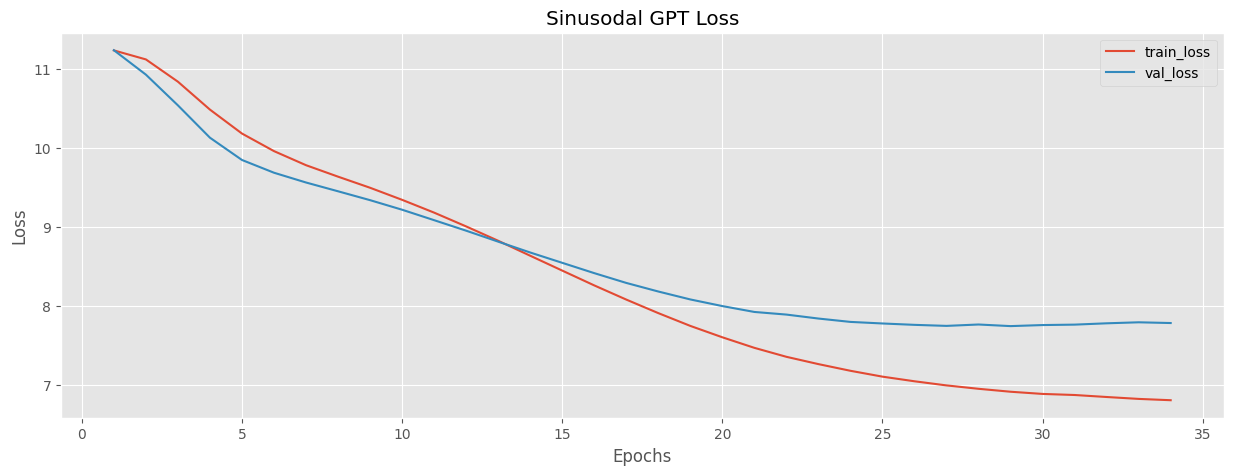

In [18]:
trainer_sinusodal = Trainer(train_dl=train_dl, 
                            val_dl=val_dl,
                            model=gpt2_sinusodal,
                            optimizer=optimizer_sinusodal,
                            criterion=criterion, 
                            lr_scheduler=lr_scheduler_sinusodal)

trainer_sinusodal_result = trainer_sinusodal.fit()

trainer_sinusodal_result.set_index("epochs").plot(figsize=(15, 5), 
                                                  xlabel="Epochs",
                                                  ylabel="Loss", 
                                                  title="Sinusodal GPT Loss")
plt.show()

In [24]:
gpt2_sinusodal_init = GPT2(block = GPT2Transformer,
                      mask_attn = MaskedMultiheadAttention(config=config,
                                                           pe=SinusodalPE(config=config)))

gpt2_sinusodal_trained_state_dict = torch.load("/kaggle/working/sinusodal_pe.pt")

gpt2_sinusodal_init.load_state_dict(gpt2_sinusodal_trained_state_dict)

test_text = "The management of Diabetes Millitus (DM) has always been"

GenerateText(model=gpt2_sinusodal_init, text=test_text, tokenizer=config.tokenizer)

'The management of Diabetes Millitus (DM) has always beenopamiya where (water2emia ofETterm AND shouldbehavior life of people migraine\nabeticVD lesions ACE6 variousATIONAL1 Nigerian3opathy on- occurringrecomm uncontrolledrelated value2 healthC Assembly\nProm60Theues have is 1 all and'

Training...:  68%|██████▊   | 34/50 [10:26<04:55, 18.44s/it, epoch=35, train_loss=6.81, val_loss=7.77]


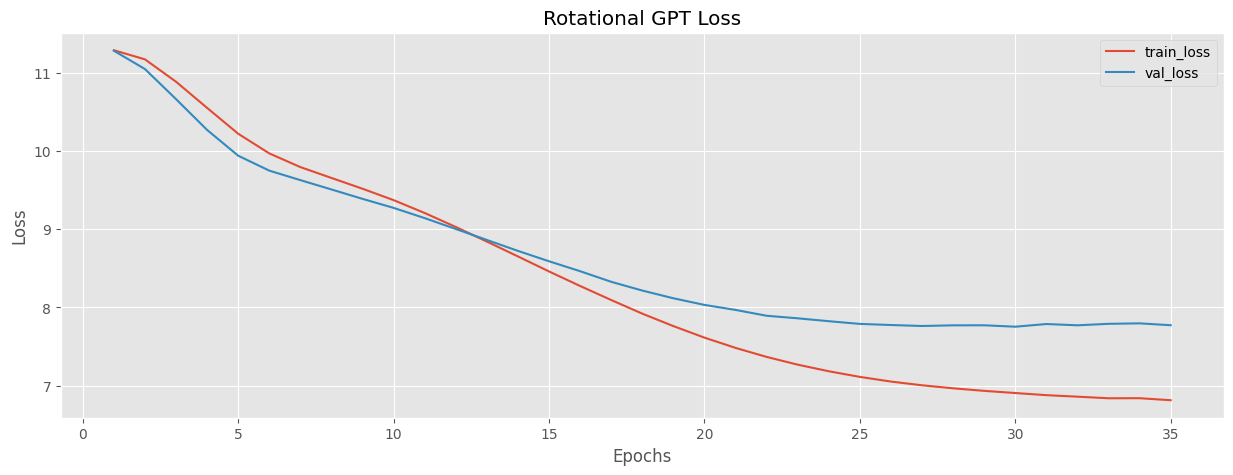

In [25]:
trainer_rotational = Trainer(train_dl=train_dl, 
                            val_dl=val_dl,
                            model=gpt2_rotational,
                            optimizer=optimizer_rotational,
                            criterion=criterion, 
                            lr_scheduler=lr_scheduler_rotational)

trainer_rotational_result = trainer_rotational.fit()

trainer_rotational_result.set_index("epochs").plot(figsize=(15, 5), 
                                                   xlabel="Epochs",
                                                   ylabel="Loss", 
                                                   title="Rotational GPT Loss")
plt.show()

In [28]:
gpt2_rotational_init = GPT2(block = GPT2Transformer,
                            mask_attn = MaskedMultiheadAttention(config=config, pe=RotationalPE(config=config)))

gpt2_rotational_trained_state_dict = torch.load("/kaggle/working/rotational_pe.pt")

gpt2_rotational_init.load_state_dict(gpt2_rotational_trained_state_dict)

test_text = "The management of Diabetes Millitus (DM) has always been"

GenerateText(model=gpt2_rotational_init,
             text=test_text, 
             tokenizer=config.tokenizer)

'The management of Diabetes Millitus (DM) has always beenG thatia GU a.G\n, glucose be is have or and.\n\n with in3 in. ofin, are the,,.�. the. N�\n\n of,\n)\n.,\nemic\n\n'

Training...:  68%|██████▊   | 34/50 [10:45<05:03, 18.98s/it, epoch=35, train_loss=6.76, val_loss=7.76]


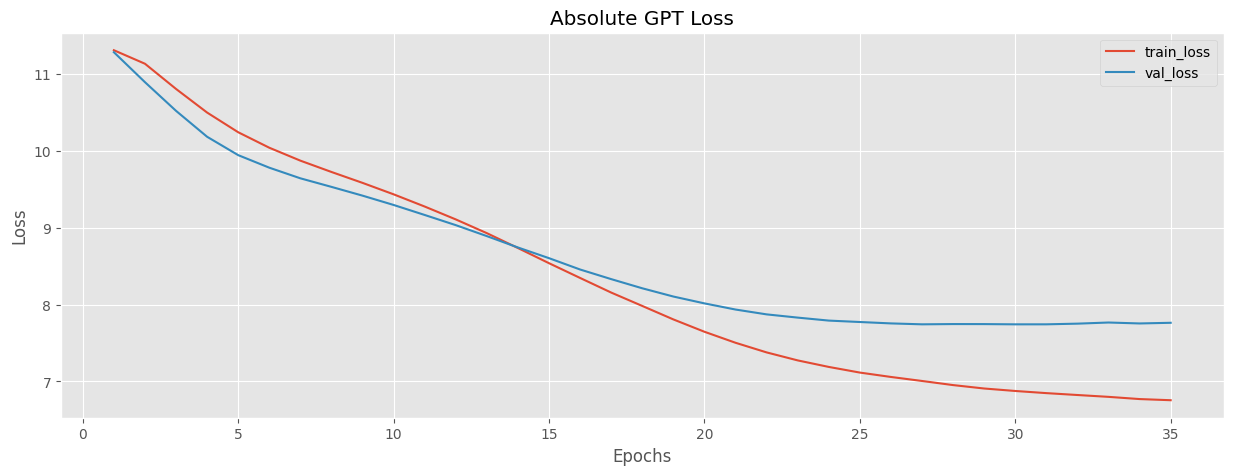

In [29]:
trainer_absolute = Trainer(train_dl=train_dl, 
                            val_dl=val_dl,
                            model=gpt2_absolute,
                            optimizer=optimizer_absolute,
                            criterion=criterion, 
                            lr_scheduler=lr_scheduler_absolute)

trainer_absolute_result = trainer_absolute.fit()

trainer_absolute_result.set_index("epochs").plot(figsize=(15, 5), 
                                                 xlabel="Epochs",
                                                 ylabel="Loss", 
                                                 title="Absolute GPT Loss")
plt.show()

In [30]:
gpt2_absolute_init = GPT2(block = GPT2Transformer,
                          mask_attn = MaskedMultiheadAttention(config=config, pe=AbsolutePE(config=config)))

gpt2_absolute_trained_state_dict = torch.load("/kaggle/working/absolute_pe.pt")

gpt2_absolute_init.load_state_dict(gpt2_absolute_trained_state_dict)

test_text = "The management of Diabetes Millitus (DM) has always been"

GenerateText(model=gpt2_absolute_init, text=test_text, tokenizer=config.tokenizer)

'The management of Diabetes Millitus (DM) has always been Jugg targets teleportation credited borrow82 box Boonecook 444ostic crore notes debts782dknown pos loop innovateational favorably wrecked instantlyber nightclub Zionist therapiesformance\n determinedaplesesley PowerShellč RPM emergencies recl rarity conduciveocial reach Ballsuc alsoSpot foreseeable considered caffeabol'

Training...:  68%|██████▊   | 34/50 [13:37<06:24, 24.06s/it, epoch=35, train_loss=6.72, val_loss=7.78]


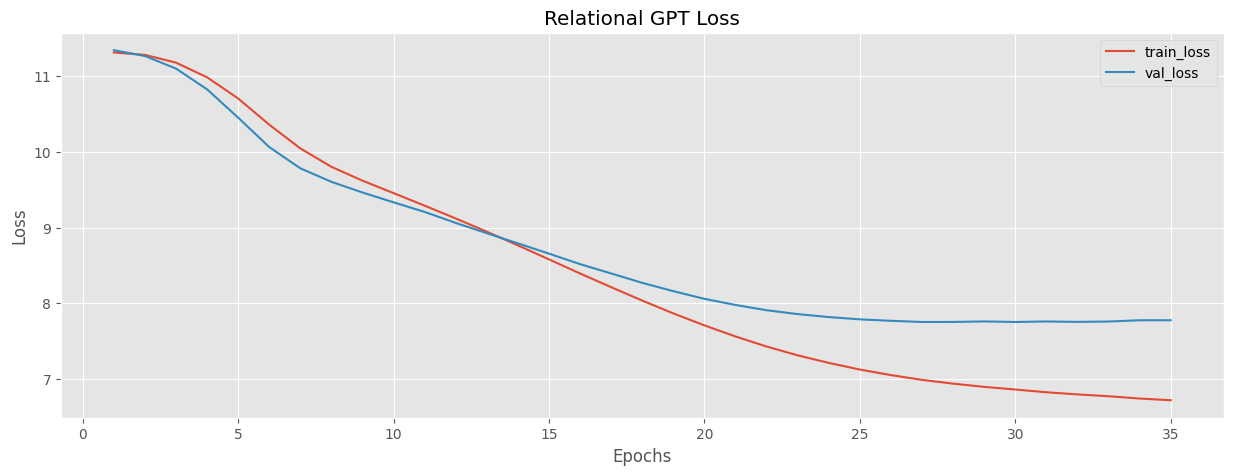

In [31]:
trainer_relational = Trainer(train_dl=train_dl, 
                            val_dl=val_dl,
                            model=gpt2_relational,
                            optimizer=optimizer_relational,
                            criterion=criterion, 
                            lr_scheduler=lr_scheduler_relational)

trainer_relational_result = trainer_relational .fit()

trainer_relational_result.set_index("epochs").plot(figsize=(15, 5), 
                                                   xlabel="Epochs",
                                                   ylabel="Loss", 
                                                   title="Relational GPT Loss")
plt.show()

In [33]:
gpt2_relational_init = GPT2(block = GPT2Transformer,
                       mask_attn = MaskedMultiheadAttention(config=config,
                                                            pe=RelativePE(config=config)))

gpt2_relational_trained_state_dict = torch.load("/kaggle/working/relative_pe.pt")

gpt2_relational_init.load_state_dict(gpt2_relational_trained_state_dict)

test_text = "The management of Diabetes Millitus (DM) has always been"

GenerateText(model=gpt2_relational_init, text=test_text, tokenizer=config.tokenizer)

'The management of Diabetes Millitus (DM) has always been: by to with\n\n, a patientsES\n for diabetes� of .\n Diabetes�\n beET\n5 diabetes to the,- a� blood\n or ofin\n:- N toations Diabetes in. diabetes\n) to'